## Session 7: Looking ahead to Euro 2029

**Question:** What does the data suggest about England's chances of a 
third consecutive Euros title in 2029?

**Approach:** Compare England, Spain and Germany across the last four 
major tournaments (World Cup 2019, Euro 2022, World Cup 2023, Euro 2025) 
to see who is trending up or down.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsbombpy import sb

print("Libraries loaded")

Libraries loaded


In [2]:
tournaments = {
    "World Cup 2019": (72, 30),
    "Euro 2022": (53, 106),
    "World Cup 2023": (72, 107),
    "Euro 2025": (53, 315),
}

teams = ["England", "Spain", "Germany"]

In [3]:
all_shots = []
pattern = "|".join(teams)

for name, (comp_id, season_id) in tournaments.items():
    matches = sb.matches(competition_id=comp_id, season_id=season_id)
    ours = matches[
        matches["home_team"].str.contains(pattern) |
        matches["away_team"].str.contains(pattern)
    ]
    print(f"{name}: {len(ours)} matches")

    for match_id in ours["match_id"]:
        events = sb.events(match_id=match_id)
        match_shots = events[(events["type"] == "Shot") & (events["period"] < 5)].copy()
        match_shots["tournament"] = name
        all_shots.append(match_shots)

shots = pd.concat(all_shots)

shots[["x", "y"]] = pd.DataFrame(shots["location"].tolist(), index=shots.index)
keep = ["tournament", "match_id", "team", "player", "minute", "period",
        "shot_type", "shot_outcome", "shot_statsbomb_xg", "shot_key_pass_id", "x", "y"]
shots = shots[keep]

os.makedirs("data", exist_ok=True)
shots.to_csv("data/shots_2019_2025.csv", index=False)
shots.shape

C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


World Cup 2019: 15 matches


C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open

Euro 2022: 13 matches


C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open

World Cup 2023: 16 matches


C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open

Euro 2025: 15 matches


C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\georg\OneDrive\Desktop\Portfolio\womens-football-dashboard\.venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open

(1594, 12)

In [4]:
shots = pd.read_csv("data/shots_2019_2025.csv")
shots["is_goal"] = shots["shot_outcome"] == "Goal"
shots.head()

,tournament,match_id,team,player,minute,period,shot_type,shot_outcome,shot_statsbomb_xg,shot_key_pass_id,x,y,is_goal
0,World Cup 2019,69301,Sweden Women's,Kosovare Asllani,10,1,Open Play,Goal,0.105188,NaN,104.7,45.5,True
1,World Cup 2019,69301,Sweden Women's,Eva Sofia Jakobsson,15,1,Open Play,Saved to Post,0.039004,ab485447-f5f4-4b3d-ade6-e3c62741fbbc,110.9,53.1,False
2,World Cup 2019,69301,Sweden Women's,Eva Sofia Jakobsson,21,1,Open Play,Goal,0.035328,5506b1d4-fe6c-460d-acdc-104cd85884ba,107.8,26.1,True
3,World Cup 2019,69301,England Women's,Lucy Bronze,22,1,Open Play,Saved,0.018011,NaN,93.7,51.1,False
4,World Cup 2019,69301,England Women's,Francesca Kirby,30,1,Open Play,Goal,0.100729,6c67714a-6078-4494-8621-81133201ca20,108.0,52.7,True


In [5]:
match_team = shots.groupby(["tournament", "match_id", "team"]).agg(
    xg=("shot_statsbomb_xg", "sum"),
    goals=("is_goal", "sum")
).reset_index()

match_totals = match_team.groupby("match_id")[["xg", "goals"]].transform("sum")
match_team["xg_against"] = match_totals["xg"] - match_team["xg"]
match_team["goals_against"] = match_totals["goals"] - match_team["goals"]

ours = match_team[match_team["team"].str.contains(pattern)].copy()
ours["team"] = ours["team"].str.replace(r" (Women's|W)$", "", regex=True)

trend = ours.groupby(["team", "tournament"]).agg(
    matches=("match_id", "count"),
    xg_for=("xg", "mean"),
    xg_against=("xg_against", "mean"),
    goals_for=("goals", "mean"),
    goals_against=("goals_against", "mean")
).reset_index()

trend["xg_difference"] = trend["xg_for"] - trend["xg_against"]
trend["tournament"] = pd.Categorical(trend["tournament"], categories=list(tournaments), ordered=True)
trend = trend.sort_values(["team", "tournament"]).round(2)
trend

,team,tournament,matches,xg_for,xg_against,goals_for,goals_against,xg_difference
2,England,World Cup 2019,7,1.84,0.61,1.86,0.71,1.23
0,England,Euro 2022,6,2.63,0.84,3.50,0.33,1.79
3,England,World Cup 2023,7,1.37,1.01,1.86,0.57,0.37
1,England,Euro 2025,6,2.39,1.25,2.67,1.17,1.15
6,Germany,World Cup 2019,5,2.00,0.77,2.00,0.40,1.23
4,Germany,Euro 2022,6,1.94,0.75,2.33,0.33,1.20
7,Germany,World Cup 2023,3,1.71,0.56,2.00,1.00,1.15
5,Germany,Euro 2025,5,1.59,1.56,1.20,1.40,0.02
10,Spain,World Cup 2019,4,1.80,1.02,1.00,1.00,0.78
8,Spain,Euro 2022,4,1.54,0.74,1.50,1.25,0.79


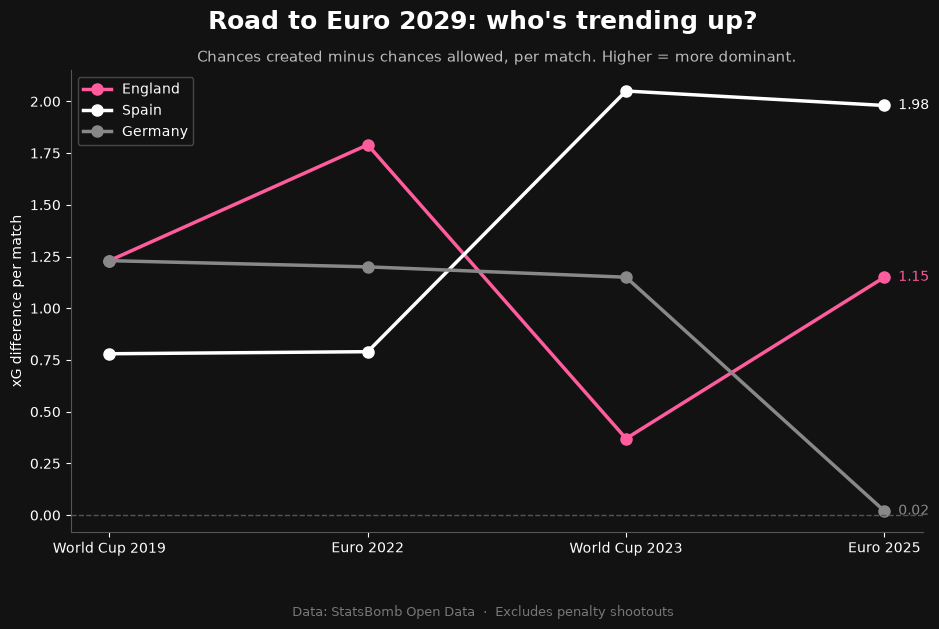

In [6]:
colours = {"England": "#FF5C9D", "Spain": "white", "Germany": "#888888"}

fig, ax = plt.subplots(figsize=(11, 6))
fig.set_facecolor("#121212")
ax.set_facecolor("#121212")

for team in teams:
    data = trend[trend["team"] == team]
    ax.plot(data["tournament"].astype(str), data["xg_difference"],
            marker="o", linewidth=2.5, markersize=8,
            color=colours[team], label=team)
    last = data.iloc[-1]
    ax.annotate(f"{last['xg_difference']:.2f}", (3, last["xg_difference"]),
                xytext=(10, 0), textcoords="offset points",
                color=colours[team], fontsize=10, va="center")

ax.axhline(0, color="#555555", linestyle="--", linewidth=1)

ax.set_ylabel("xG difference per match", color="white")
ax.tick_params(colors="white")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#555555")

fig.suptitle("Road to Euro 2029: who's trending up?", color="white",
             fontsize=18, fontweight="bold")
ax.set_title("Chances created minus chances allowed, per match. Higher = more dominant.",
             color="#BBBBBB", fontsize=11)
fig.text(0.5, -0.03, "Data: StatsBomb Open Data  ·  Excludes penalty shootouts",
         color="#777777", fontsize=9, ha="center")

ax.legend(facecolor="#121212", edgecolor="#555555", labelcolor="white")
fig.savefig("road_to_2029_trend.png", dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

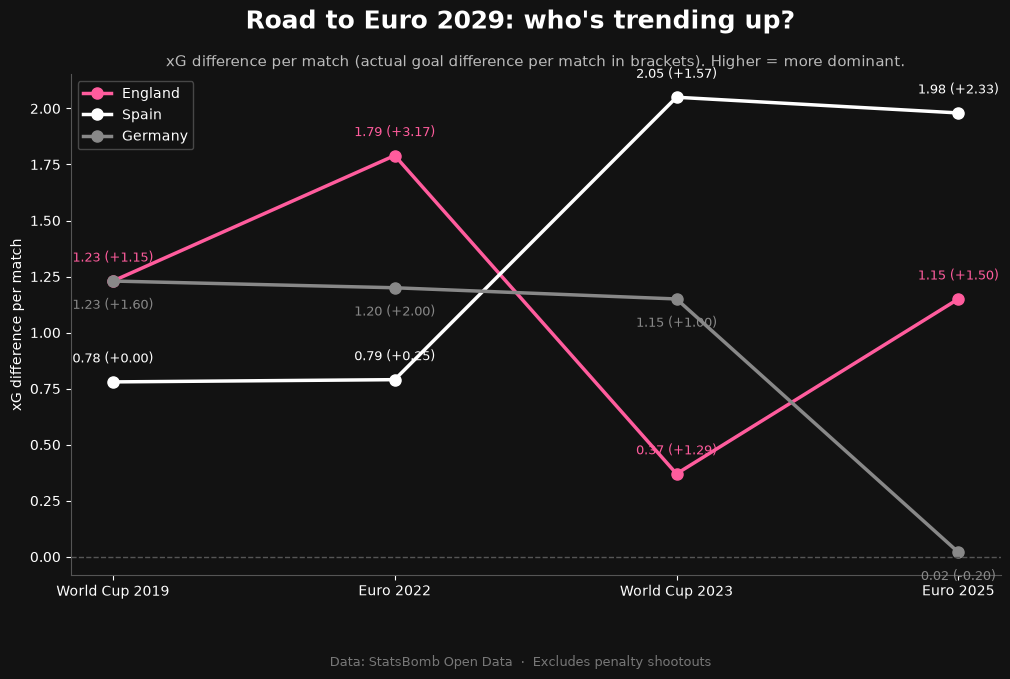

In [7]:
trend["goal_difference"] = trend["goals_for"] - trend["goals_against"]

colours = {"England": "#FF5C9D", "Spain": "white", "Germany": "#888888"}
offsets = {"England": 14, "Spain": 14, "Germany": -20}

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.set_facecolor("#121212")
ax.set_facecolor("#121212")

for team in teams:
    data = trend[trend["team"] == team]
    ax.plot(data["tournament"].astype(str), data["xg_difference"],
            marker="o", linewidth=2.5, markersize=8,
            color=colours[team], label=team)

    for i, (xgd, gd) in enumerate(zip(data["xg_difference"], data["goal_difference"])):
        ax.annotate(f"{xgd:.2f} ({gd:+.2f})", (i, xgd),
                    xytext=(0, offsets[team]), textcoords="offset points",
                    color=colours[team], fontsize=9, ha="center")

ax.axhline(0, color="#555555", linestyle="--", linewidth=1)

ax.set_ylabel("xG difference per match", color="white")
ax.tick_params(colors="white")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#555555")

fig.suptitle("Road to Euro 2029: who's trending up?", color="white",
             fontsize=18, fontweight="bold")
ax.set_title("xG difference per match (actual goal difference per match in brackets). "
             "Higher = more dominant.", color="#BBBBBB", fontsize=11)
fig.text(0.5, -0.03, "Data: StatsBomb Open Data  ·  Excludes penalty shootouts",
         color="#777777", fontsize=9, ha="center")

ax.legend(facecolor="#121212", edgecolor="#555555", labelcolor="white")
fig.savefig("road_to_2029_trend.png", dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

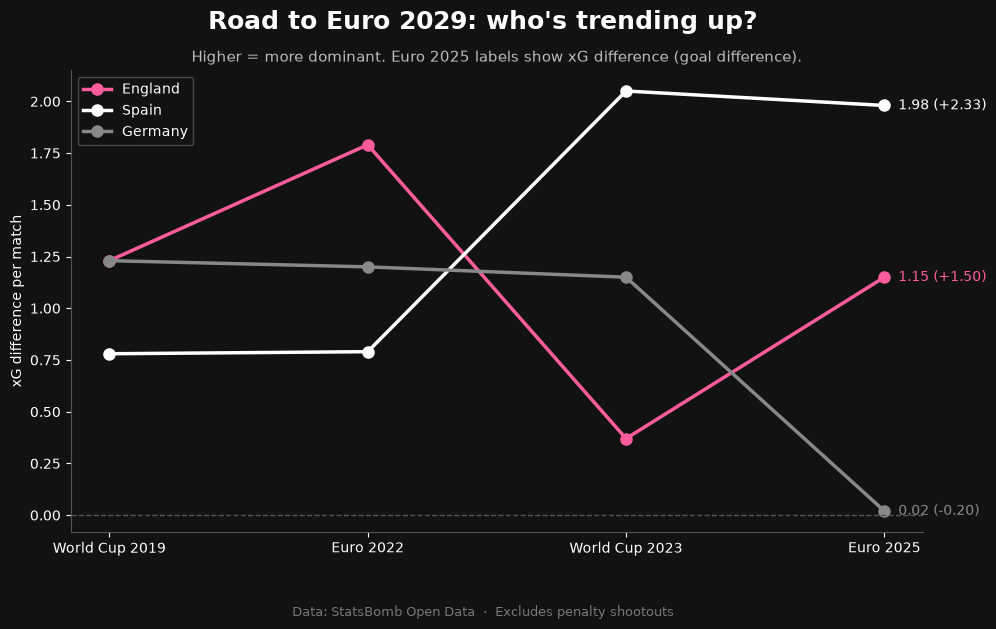

In [8]:
trend["goal_difference"] = trend["goals_for"] - trend["goals_against"]

colours = {"England": "#FF5C9D", "Spain": "white", "Germany": "#888888"}

fig, ax = plt.subplots(figsize=(11, 6))
fig.set_facecolor("#121212")
ax.set_facecolor("#121212")

for team in teams:
    data = trend[trend["team"] == team]
    ax.plot(data["tournament"].astype(str), data["xg_difference"],
            marker="o", linewidth=2.5, markersize=8,
            color=colours[team], label=team)

    last = data.iloc[-1]
    ax.annotate(f"{last['xg_difference']:.2f} ({last['goal_difference']:+.2f})",
                (3, last["xg_difference"]), xytext=(10, 0), textcoords="offset points",
                color=colours[team], fontsize=10, va="center")

ax.axhline(0, color="#555555", linestyle="--", linewidth=1)

ax.set_ylabel("xG difference per match", color="white")
ax.tick_params(colors="white")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#555555")

fig.suptitle("Road to Euro 2029: who's trending up?", color="white",
             fontsize=18, fontweight="bold")
ax.set_title("Higher = more dominant. Euro 2025 labels show xG difference (goal difference).",
             color="#BBBBBB", fontsize=11)
fig.text(0.5, -0.03, "Data: StatsBomb Open Data  ·  Excludes penalty shootouts",
         color="#777777", fontsize=9, ha="center")

ax.legend(facecolor="#121212", edgecolor="#555555", labelcolor="white")
fig.savefig("road_to_2029_trend.png", dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

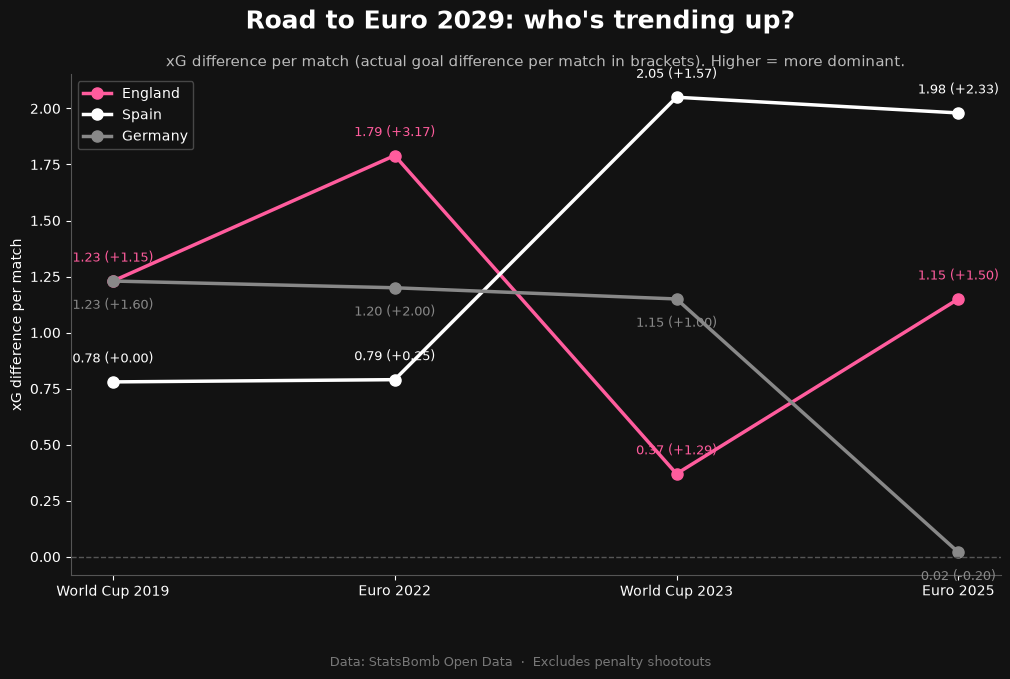

In [9]:
trend["goal_difference"] = trend["goals_for"] - trend["goals_against"]

colours = {"England": "#FF5C9D", "Spain": "white", "Germany": "#888888"}
offsets = {"England": 14, "Spain": 14, "Germany": -20}

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.set_facecolor("#121212")
ax.set_facecolor("#121212")

for team in teams:
    data = trend[trend["team"] == team]
    ax.plot(data["tournament"].astype(str), data["xg_difference"],
            marker="o", linewidth=2.5, markersize=8,
            color=colours[team], label=team)

    for i, (xgd, gd) in enumerate(zip(data["xg_difference"], data["goal_difference"])):
        ax.annotate(f"{xgd:.2f} ({gd:+.2f})", (i, xgd),
                    xytext=(0, offsets[team]), textcoords="offset points",
                    color=colours[team], fontsize=9, ha="center")

ax.axhline(0, color="#555555", linestyle="--", linewidth=1)

ax.set_ylabel("xG difference per match", color="white")
ax.tick_params(colors="white")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#555555")

fig.suptitle("Road to Euro 2029: who's trending up?", color="white",
             fontsize=18, fontweight="bold")
ax.set_title("xG difference per match (actual goal difference per match in brackets). "
             "Higher = more dominant.", color="#BBBBBB", fontsize=11)
fig.text(0.5, -0.03, "Data: StatsBomb Open Data  ·  Excludes penalty shootouts",
         color="#777777", fontsize=9, ha="center")

ax.legend(facecolor="#121212", edgecolor="#555555", labelcolor="white")
fig.savefig("road_to_2029_trend.png", dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

In [10]:
ages = pd.read_csv("data/england_ages.csv", parse_dates=["birth_date"])
stats = pd.read_csv("data/england_players_euro2025.csv", index_col="player")

missing = set(stats.index) - set(ages["player"])
print("Players in stats but not in ages:", missing)

squad = stats.merge(ages, left_index=True, right_on="player")

euro_2029 = pd.Timestamp("2029-07-01")
squad["age_2029"] = ((euro_2029 - squad["birth_date"]).dt.days / 365.25).round(1)
squad["involvement"] = squad["xg"] + squad["xg_assisted"]

squad[["player", "age_2029", "xg", "xg_assisted", "involvement"]].sort_values("involvement", ascending=False)

Players in stats but not in ages: set()


,player,age_2029,xg,xg_assisted,involvement
0,Alessia Russo,30.4,2.41,1.21,3.62
1,Ella Toone,29.8,2.32,1.16,3.48
2,Lauren Hemp,28.9,1.55,1.34,2.89
4,Chloe Kelly,31.5,0.88,1.15,2.03
3,Lauren James,27.8,1.36,0.50,1.86
7,Bethany Mead,34.1,0.60,0.57,1.17
9,Agnes Beever-Jones,25.9,0.49,0.66,1.15
6,Georgia Stanway,30.5,0.83,0.31,1.14
10,Keira Walsh,32.2,0.39,0.65,1.04
5,Michelle Agyemang,23.4,0.84,0.17,1.01


In [11]:
squad["age_group"] = np.where(squad["age_2029"] >= 30, "30 or older in 2029", "Under 30 in 2029")

share = squad.groupby("age_group")["involvement"].sum()
share_pct = (share / share.sum() * 100).round(1)
share_pct

age_group
30 or older in 2029    49.8
Under 30 in 2029       50.2
Name: involvement, dtype: float64

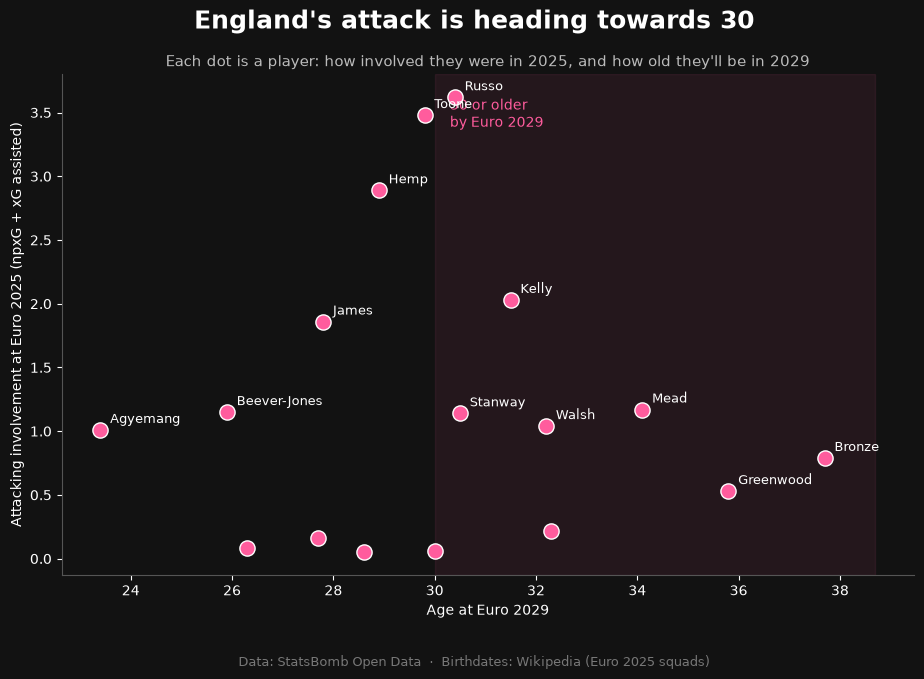

In [12]:
fig, ax = plt.subplots(figsize=(11, 6.5))
fig.set_facecolor("#121212")
ax.set_facecolor("#121212")

ax.axvspan(30, squad["age_2029"].max() + 1, color="#FF5C9D", alpha=0.08)
ax.text(30.3, squad["involvement"].max(), "30 or older\nby Euro 2029",
        color="#FF5C9D", fontsize=10, va="top")

ax.scatter(squad["age_2029"], squad["involvement"], s=120,
           color="#FF5C9D", edgecolors="white", zorder=3)
for _, row in squad[squad["involvement"] >= 0.5].iterrows():
    ax.annotate(row["player"].split()[-1], (row["age_2029"], row["involvement"]),
                xytext=(7, 5), textcoords="offset points", color="white", fontsize=9)

ax.set_xlabel("Age at Euro 2029", color="white")
ax.set_ylabel("Attacking involvement at Euro 2025 (npxG + xG assisted)", color="white")
ax.tick_params(colors="white")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#555555")

fig.suptitle("England's attack is heading towards 30", color="white",
             fontsize=18, fontweight="bold")
ax.set_title("Each dot is a player: how involved they were in 2025, and how old they'll be in 2029",
             color="#BBBBBB", fontsize=11)
fig.text(0.5, -0.03, "Data: StatsBomb Open Data  ·  Birthdates: Wikipedia (Euro 2025 squads)",
         color="#777777", fontsize=9, ha="center")

fig.savefig("england_age_2029.png", dpi=200, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()